In [2]:
import pandas as pd
df = pd.read_csv("matches.csv")
print("Dataset loaded!")
print("Shape:", df.shape)
print(df.head())

Dataset loaded!
Shape: (756, 18)
   id  season       city        date                        team1  \
0   1    2017  Hyderabad  2017-04-05          Sunrisers Hyderabad   
1   2    2017       Pune  2017-04-06               Mumbai Indians   
2   3    2017     Rajkot  2017-04-07                Gujarat Lions   
3   4    2017     Indore  2017-04-08       Rising Pune Supergiant   
4   5    2017  Bangalore  2017-04-08  Royal Challengers Bangalore   

                         team2                  toss_winner toss_decision  \
0  Royal Challengers Bangalore  Royal Challengers Bangalore         field   
1       Rising Pune Supergiant       Rising Pune Supergiant         field   
2        Kolkata Knight Riders        Kolkata Knight Riders         field   
3              Kings XI Punjab              Kings XI Punjab         field   
4             Delhi Daredevils  Royal Challengers Bangalore           bat   

   result  dl_applied                       winner  win_by_runs  \
0  normal           0 

In [3]:
print("=== DATA TYPES ===")
print(df.dtypes)
print()
print("=== MISSING VALUES ===")
print(df.isnull().sum())

=== DATA TYPES ===
id                  int64
season              int64
city               object
date               object
team1              object
team2              object
toss_winner        object
toss_decision      object
result             object
dl_applied          int64
winner             object
win_by_runs         int64
win_by_wickets      int64
player_of_match    object
venue              object
umpire1            object
umpire2            object
umpire3            object
dtype: object

=== MISSING VALUES ===
id                   0
season               0
city                 7
date                 0
team1                0
team2                0
toss_winner          0
toss_decision        0
result               0
dl_applied           0
winner               4
win_by_runs          0
win_by_wickets       0
player_of_match      4
venue                0
umpire1              2
umpire2              2
umpire3            637
dtype: int64


In [4]:
df = df.drop(columns=['umpire3'])
df['city'] = df['city'].fillna('Unknown')

print("Data cleaned!")
print("New shape:", df.shape)

Data cleaned!
New shape: (756, 17)


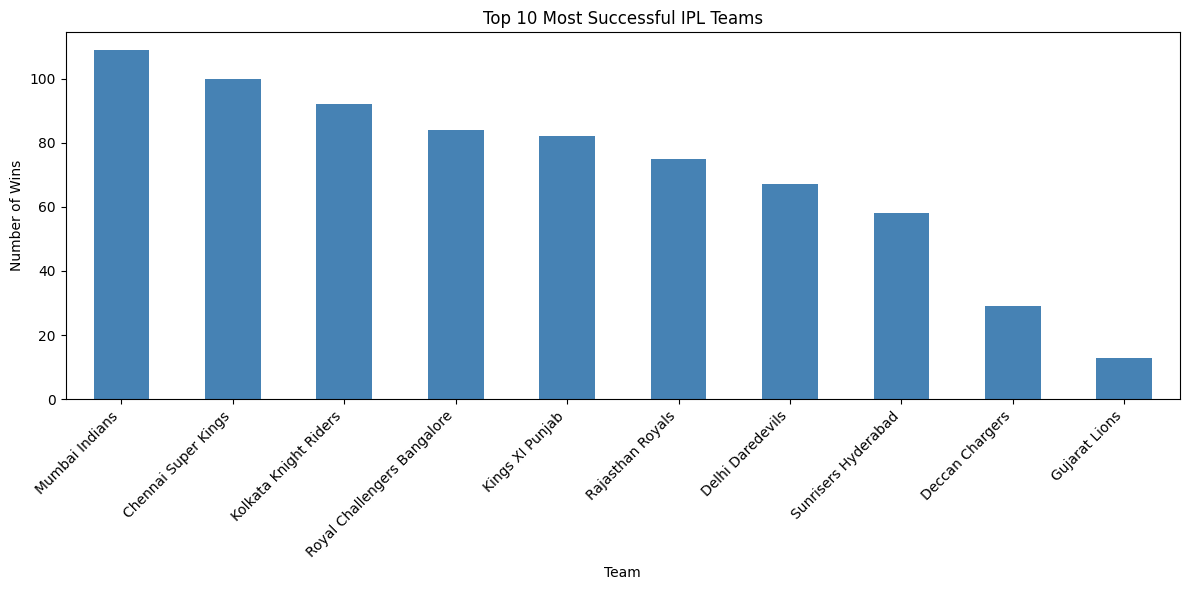

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
df['winner'].value_counts().head(10).plot(kind='bar', color='steelblue')
plt.title('Top 10 Most Successful IPL Teams')
plt.xlabel('Team')
plt.ylabel('Number of Wins')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

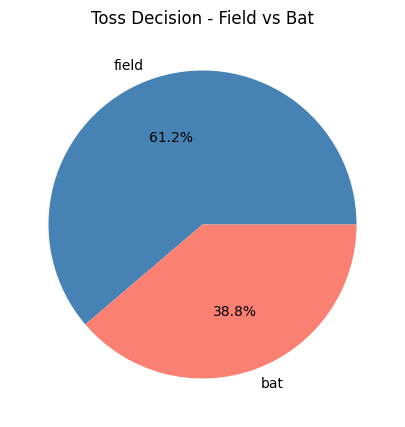

In [7]:
plt.figure(figsize=(8,5))
df['toss_decision'].value_counts().plot(kind='pie', autopct='%1.1f%%', colors=['steelblue', 'salmon'])
plt.title('Toss Decision - Field vs Bat')
plt.ylabel('')
plt.show()

Matches where toss winner won: 393
Total matches: 756
Percentage: 52.0%


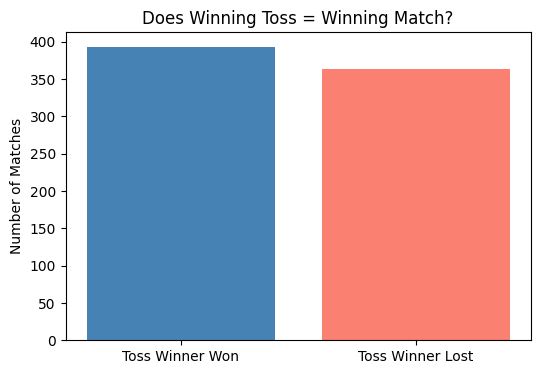

In [8]:
toss_win = df[df['toss_winner'] == df['winner']].shape[0]
total = df.shape[0]
percentage = (toss_win/total) * 100

print(f"Matches where toss winner won: {toss_win}")
print(f"Total matches: {total}")
print(f"Percentage: {percentage:.1f}%")

plt.figure(figsize=(6,4))
plt.bar(['Toss Winner Won', 'Toss Winner Lost'],
        [toss_win, total-toss_win],
        color=['steelblue', 'salmon'])
plt.title('Does Winning Toss = Winning Match?')
plt.ylabel('Number of Matches')
plt.show()

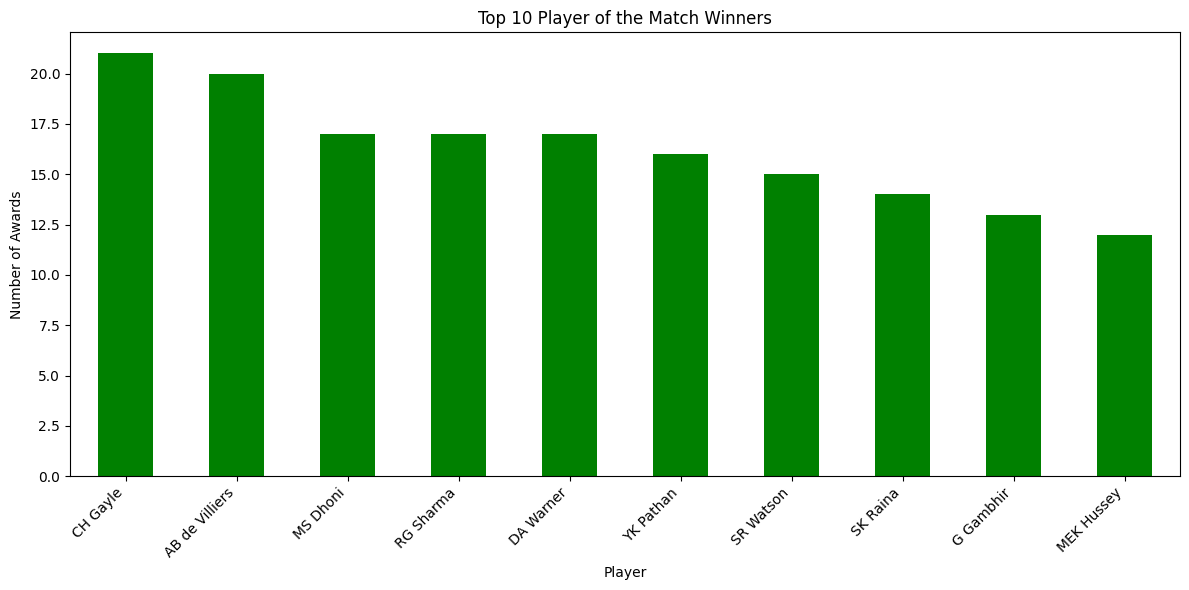

In [9]:
plt.figure(figsize=(12,6))
df['player_of_match'].value_counts().head(10).plot(kind='bar', color='green')
plt.title('Top 10 Player of the Match Winners')
plt.xlabel('Player')
plt.ylabel('Number of Awards')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

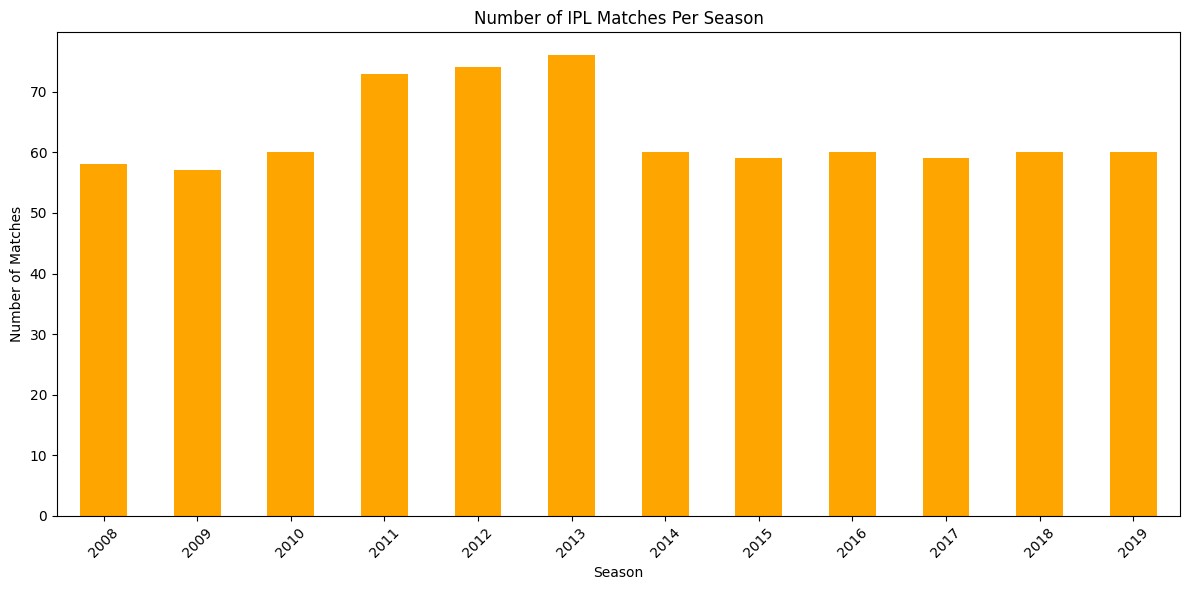

In [10]:
plt.figure(figsize=(12,6))
df['season'].value_counts().sort_index().plot(kind='bar', color='orange')
plt.title('Number of IPL Matches Per Season')
plt.xlabel('Season')
plt.ylabel('Number of Matches')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

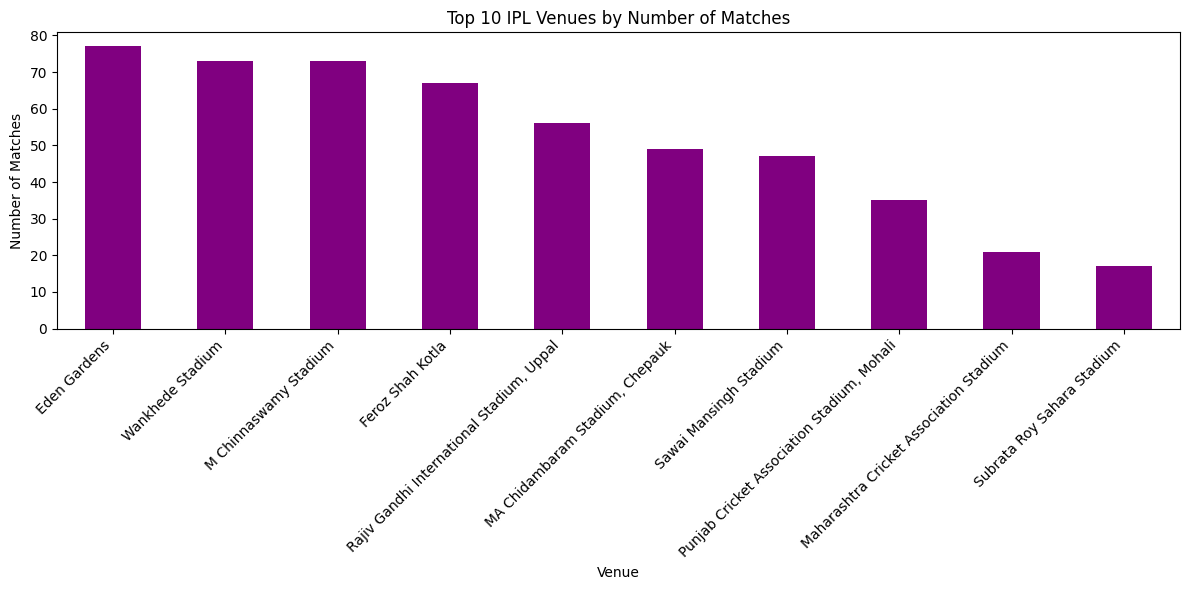

In [11]:
plt.figure(figsize=(12,6))
df['venue'].value_counts().head(10).plot(kind='bar', color='purple')
plt.title('Top 10 IPL Venues by Number of Matches')
plt.xlabel('Venue')
plt.ylabel('Number of Matches')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

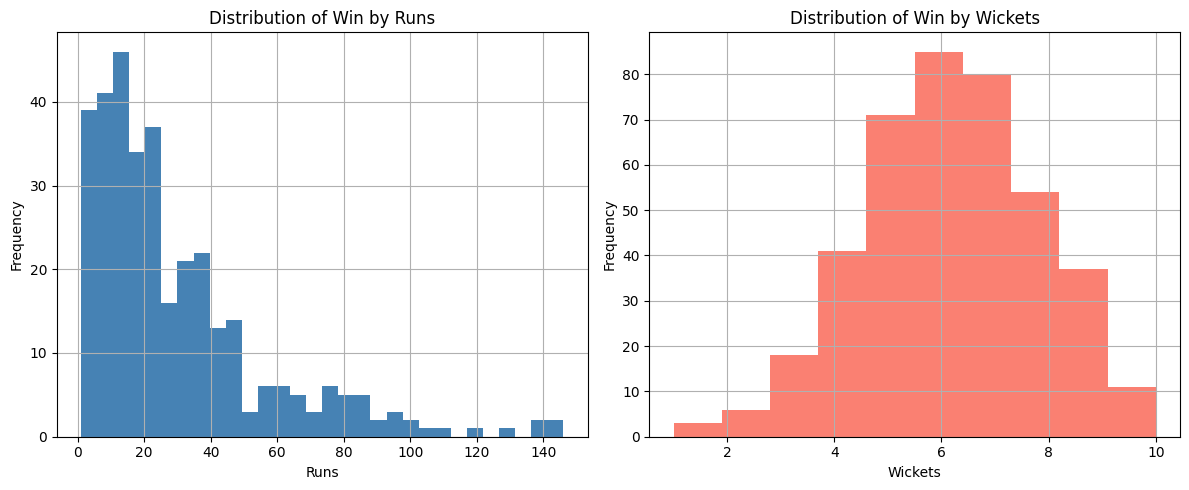

In [13]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
df[df['win_by_runs'] > 0]['win_by_runs'].hist(bins=30, color='steelblue')
plt.title('Distribution of Win by Runs')
plt.xlabel('Runs')
plt.ylabel('Frequency')

plt.subplot(1,2,2)
df[df['win_by_wickets'] > 0]['win_by_wickets'].hist(bins=10, color='salmon')
plt.title('Distribution of Win by Wickets')
plt.xlabel('Wickets')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

In [14]:
print("=== IPL DATA ANALYSIS - KEY INSIGHTS ===")
print()
print(f"Total matches analyzed: {df.shape[0]}")
print(f"Seasons covered: {df['season'].min()} to {df['season'].max()}")
print(f"Total teams: {df['team1'].nunique()}")
print(f"Total venues: {df['venue'].nunique()}")
print()
print(f"Most successful team: {df['winner'].value_counts().index[0]} ({df['winner'].value_counts().iloc[0]} wins)")
print(f"Best player of match: {df['player_of_match'].value_counts().index[0]} ({df['player_of_match'].value_counts().iloc[0]} awards)")
print(f"Most used venue: {df['venue'].value_counts().index[0]}")
print()
toss_win = df[df['toss_winner'] == df['winner']].shape[0]
print(f"Toss winner won the match: {(toss_win/df.shape[0]*100):.1f}% of the time")

=== IPL DATA ANALYSIS - KEY INSIGHTS ===

Total matches analyzed: 756
Seasons covered: 2008 to 2019
Total teams: 15
Total venues: 41

Most successful team: Mumbai Indians (109 wins)
Best player of match: CH Gayle (21 awards)
Most used venue: Eden Gardens

Toss winner won the match: 52.0% of the time
